In [3]:
!pip install hmmlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 6.3 MB/s eta 0:00:00


In [4]:
import os
import pandas as pd
import numpy as np
import pathlib as Path
from scipy.fft import fft
from scipy.stats import pearsonr

In [5]:
from hmmlearn import hmm
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load All Recordings
In the next step the following is being done:

1. Load the `Accelerometer.csv` and `Gyroscope.csv` files
2. Rename the columns so they don't clash when merged (e.g. `x` → `acc_x`)
3. Merge the two files by aligning their timestamps using `merge_asof` (nearest match)
4. Tag each row with its activity label and recording name

In [7]:
from pathlib import Path




TRAIN_PATH = Path('/content/drive/MyDrive/Colab Notebooks/dataset_for_hmm')   # training dataset
TEST_PATH  = Path('/content/drive/MyDrive/Colab Notebooks/dataset')           # unseen test dataset
ACTIVITIES = ['jumping', 'motionless', 'standing', 'walking']


def load_dataset(dataset_path: Path) -> pd.DataFrame:
    """Loads all recordings from a dataset folder into one combined DataFrame."""
    all_recordings = []

    for activity in ACTIVITIES:
        for rec_path in sorted((dataset_path / activity).iterdir()):
            if not rec_path.is_dir():
                continue

            acc = pd.read_csv(rec_path / 'Accelerometer.csv')
            gyr = pd.read_csv(rec_path / 'Gyroscope.csv')

            acc = acc.rename(columns={'x': 'acc_x', 'y': 'acc_y', 'z': 'acc_z'})
            gyr = gyr.rename(columns={'x': 'gyr_x', 'y': 'gyr_y', 'z': 'gyr_z'})

            merged = pd.merge_asof(
                acc.sort_values('seconds_elapsed'),
                gyr[['seconds_elapsed', 'gyr_x', 'gyr_y', 'gyr_z']].sort_values('seconds_elapsed'),
                on='seconds_elapsed',
                direction='nearest'
            )
            merged['activity']  = activity
            merged['recording'] = rec_path.name
            all_recordings.append(merged)

    return pd.concat(all_recordings, ignore_index=True)


train_raw = load_dataset(TRAIN_PATH)
test_raw  = load_dataset(TEST_PATH)

print('=== TRAINING DATASET (dataset_for_hmm) ===')
print(f'Total rows: {len(train_raw):,}')
print(train_raw.groupby('activity').size().rename('rows'))
print()
print('=== TEST DATASET (dataset) ===')
print(f'Total rows: {len(test_raw):,}')
print(test_raw.groupby('activity').size().rename('rows'))

=== TRAINING DATASET (dataset_for_hmm) ===
Total rows: 19,860
activity
jumping       4648
motionless    4920
standing      5405
walking       4887
Name: rows, dtype: int64

=== TEST DATASET (dataset) ===
Total rows: 23,782
activity
jumping       6174
motionless    5543
standing      7136
walking       4929
Name: rows, dtype: int64


# Visualizing the Plots of Accelerometer.csv and Gyroscope.csv
expected visuals for each activity:

- **Jumping** should show large, periodic spikes (each jump)
- **Walking** should show a smooth, rhythmic oscillation
- **Standing** should be mostly flat with small noise
- **Motionless** should be nearly a straight line

NB the sudden spikes at the end and start of motionless accelerometer plot are a result of the action of placing the phone on a table and lifting it from thr table. according to my personal observations


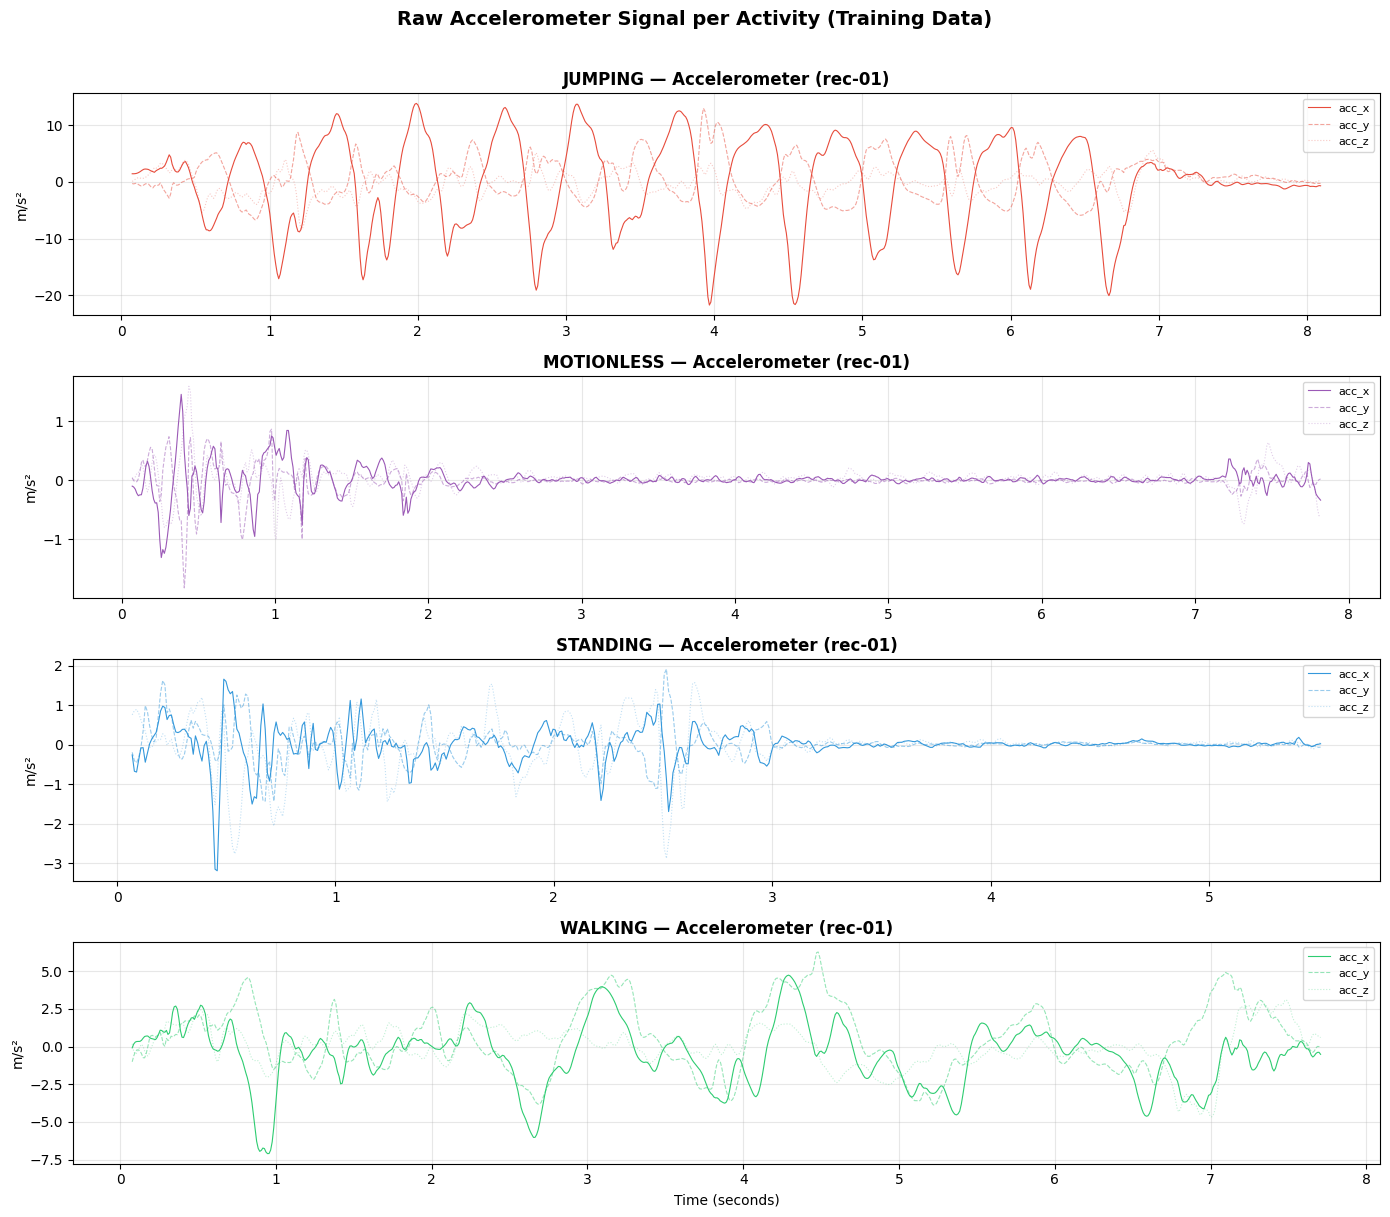

In [8]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=False)
colors = {'jumping': '#e74c3c', 'walking': '#2ecc71',
          'standing': '#3498db', 'motionless': '#9b59b6'}

for ax, activity in zip(axes, ACTIVITIES):
    sample = train_raw[(train_raw['activity'] == activity) &
                       (train_raw['recording'] == 'rec-01')].copy()
    ax.plot(sample['seconds_elapsed'], sample['acc_x'],
            color=colors[activity], linewidth=0.8, label='acc_x')
    ax.plot(sample['seconds_elapsed'], sample['acc_y'],
            color=colors[activity], linewidth=0.8, alpha=0.5, linestyle='--', label='acc_y')
    ax.plot(sample['seconds_elapsed'], sample['acc_z'],
            color=colors[activity], linewidth=0.8, alpha=0.3, linestyle=':', label='acc_z')
    ax.set_title(f'{activity.upper()} — Accelerometer (rec-01)', fontweight='bold')
    ax.set_ylabel('m/s\u00b2')
    ax.legend(loc='upper right', fontsize=8)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (seconds)')
plt.suptitle('Raw Accelerometer Signal per Activity (Training Data)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Feature Extraction

We can't feed 100 raw numbers per second into the HMM — it needs compact, meaningful summaries.
We slide a **1-second window** (100 samples) across each recording with **50% overlap** (step = 50 samples).
For each window we compute:

**Time-domain features** (describe the shape of the signal):
- `mean` of each axis — is the phone tilted? accelerating?
- `std` (standard deviation) — how much does it vary?
- `sma` (Signal Magnitude Area) — overall energy = sum of |x| + |y| + |z|
- `corr_xy` — do x and y move together? (useful for walking gait)

**Frequency-domain features** (describe the rhythm of the signal):
- `dom_freq` — the dominant frequency (jumping has a clear ~2 Hz rhythm)
- `spectral_energy` — total power in the frequency spectrum

In [ ]:
WINDOW_SIZE = 100
STEP_SIZE   = 50
SAMPLE_RATE = 100
SENSOR_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


def extract_features(window: pd.DataFrame) -> dict:
    feats = {}
    for col in SENSOR_COLS:
        signal = window[col].values
        feats[f'{col}_mean'] = np.mean(signal)
        feats[f'{col}_std']  = np.std(signal)
        fft_vals = np.abs(fft(signal))[:WINDOW_SIZE // 2]
        freqs    = np.linspace(0, SAMPLE_RATE / 2, len(fft_vals))
        feats[f'{col}_dom_freq']        = freqs[np.argmax(fft_vals)]
        feats[f'{col}_spectral_energy'] = np.sum(fft_vals ** 2)
    feats['acc_sma']     = (np.sum(np.abs(window['acc_x'].values)) +
                            np.sum(np.abs(window['acc_y'].values)) +
                            np.sum(np.abs(window['acc_z'].values))) / WINDOW_SIZE
    feats['acc_corr_xy'] = pearsonr(window['acc_x'].values, window['acc_y'].values)[0]
    feats['acc_corr_xz'] = pearsonr(window['acc_x'].values, window['acc_z'].values)[0]
    return feats


def extract_all_features(raw_df: pd.DataFrame) -> pd.DataFrame:
    feature_rows = []
    for activity in ACTIVITIES:
        for rec_name, rec_df in raw_df[raw_df['activity'] == activity].groupby('recording'):
            rec_df = rec_df.reset_index(drop=True)
            for start in range(0, len(rec_df) - WINDOW_SIZE + 1, STEP_SIZE):
                feats = extract_features(rec_df.iloc[start: start + WINDOW_SIZE])
                feats['activity']  = activity
                feats['recording'] = rec_name
                feature_rows.append(feats)
    return pd.DataFrame(feature_rows)


train_features = extract_all_features(train_raw)
test_features  = extract_all_features(test_raw)

print('=== TRAINING FEATURES ===')
print(f'Shape: {train_features.shape}  ({train_features.shape[0]} windows, {train_features.shape[1]-2} features)')
print(train_features.groupby('activity').size().rename('windows'))
print()
print('=== TEST FEATURES ===')
print(f'Shape: {test_features.shape}  ({test_features.shape[0]} windows, {test_features.shape[1]-2} features)')
print(test_features.groupby('activity').size().rename('windows'))

=== TRAINING FEATURES ===
Shape: (359, 29)  (359 windows, 27 features)
activity
jumping       84
motionless    89
standing      96
walking       90
Name: windows, dtype: int64

=== TEST FEATURES ===
Shape: (429, 29)  (429 windows, 27 features)
activity
jumping       112
motionless     99
standing      129
walking        89
Name: windows, dtype: int64


# Preparing Data for the HMM

In [ ]:
np.random.seed(42)

FEATURE_COLS = [c for c in train_features.columns if c not in ('activity', 'recording')]

scaler  = StandardScaler()
X_train = scaler.fit_transform(train_features[FEATURE_COLS])  # fit + transform on train
X_test  = scaler.transform(test_features[FEATURE_COLS])        # transform only on test

y_train = train_features['activity'].values
y_test  = test_features['activity'].values

print(f'X_train shape: {X_train.shape}')
print(f'X_test  shape: {X_test.shape}')
print()
print('Training windows per activity:')
for act in ACTIVITIES:
    print(f'  {act:<14}: {np.sum(y_train == act)} windows')
print()
print('Test windows per activity:')
for act in ACTIVITIES:
    print(f'  {act:<14}: {np.sum(y_test == act)} windows')

X_train shape: (359, 27)
X_test  shape: (429, 27)

Training windows per activity:
  jumping       : 84 windows
  motionless    : 89 windows
  standing      : 96 windows
  walking       : 90 windows

Test windows per activity:
  jumping       : 112 windows
  motionless    : 99 windows
  standing      : 129 windows
  walking       : 89 windows


# Training One HMM per Activity


In [ ]:
N_STATES = 3
N_ITER   = 100
models   = {}

for activity in ACTIVITIES:
    mask    = train_features['activity'] == activity
    X_act   = X_train[mask]
    lengths = train_features[mask].groupby('recording', sort=False).size().tolist()

    model = hmm.GaussianHMM(
        n_components=N_STATES,
        covariance_type='diag',
        n_iter=N_ITER,
        random_state=42
    )
    model.fit(X_act, lengths)
    models[activity] = model
    print(f'Trained HMM for {activity:<14} | converged: {model.monitor_.converged}')

print('\nAll models trained on dataset_for_hmm!')

Trained HMM for jumping        | converged: True
Trained HMM for motionless     | converged: True
Trained HMM for standing       | converged: True
Trained HMM for walking        | converged: True

All models trained on dataset_for_hmm!


# Visual Representation of Transition Matrix

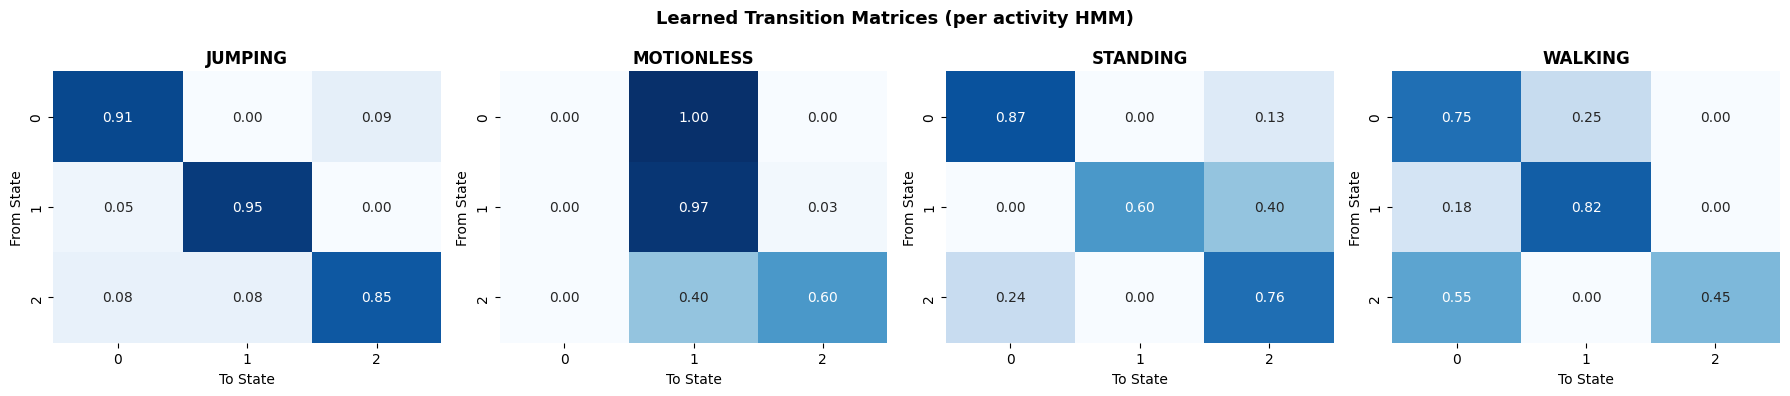

In [12]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, activity in zip(axes, ACTIVITIES):
    sns.heatmap(
        models[activity].transmat_,
        ax=ax, annot=True, fmt='.2f',
        cmap='Blues', vmin=0, vmax=1, cbar=False
    )
    ax.set_title(f'{activity.upper()}', fontweight='bold')
    ax.set_xlabel('To State')
    ax.set_ylabel('From State')

plt.suptitle('Learned Transition Matrices (per activity HMM)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Evaluating Unseen Test Data

In [17]:
y_pred = []

for activity in ACTIVITIES:
    mask     = test_features['activity'] == activity
    X_seq    = X_test[mask]
    seq_lens = test_features[mask].groupby('recording', sort=False).size().tolist()

    start = 0
    for length in seq_lens:
        seq       = X_seq[start: start + length]
        scores    = {act: models[act].score(seq) for act in ACTIVITIES}
        predicted = max(scores, key=scores.get)
        y_pred.extend([predicted] * length)
        start += length

y_pred = np.array(y_pred)

print('Classification Report (unseen dataset):')
print(classification_report(y_test, y_pred, target_names=ACTIVITIES))

Classification Report (unseen dataset):
              precision    recall  f1-score   support

     jumping       0.75      1.00      0.85       112
  motionless       1.00      1.00      1.00        99
    standing       0.83      1.00      0.91       129
     walking       1.00      0.28      0.44        89

    accuracy                           0.85       429
   macro avg       0.89      0.82      0.80       429
weighted avg       0.88      0.85      0.82       429



# Confusion Matrix

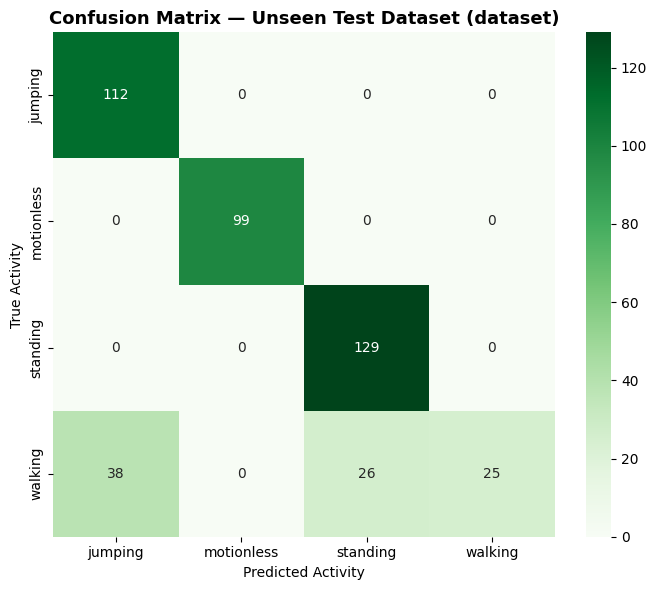

In [18]:
cm = confusion_matrix(y_test, y_pred, labels=ACTIVITIES)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=ACTIVITIES, yticklabels=ACTIVITIES
)
plt.title('Confusion Matrix — Unseen Test Dataset (dataset)', fontsize=13, fontweight='bold')
plt.ylabel('True Activity')
plt.xlabel('Predicted Activity')
plt.tight_layout()
plt.show()

# Predict with Viterbi & Evaluate

### What is Viterbi?
The Viterbi algorithm finds the **most likely hidden state sequence** given the observations.
Think of it as the most plausible explanation for what the phone was doing at each moment.
Here it also helps us decode which sub-state the activity was in at each window.

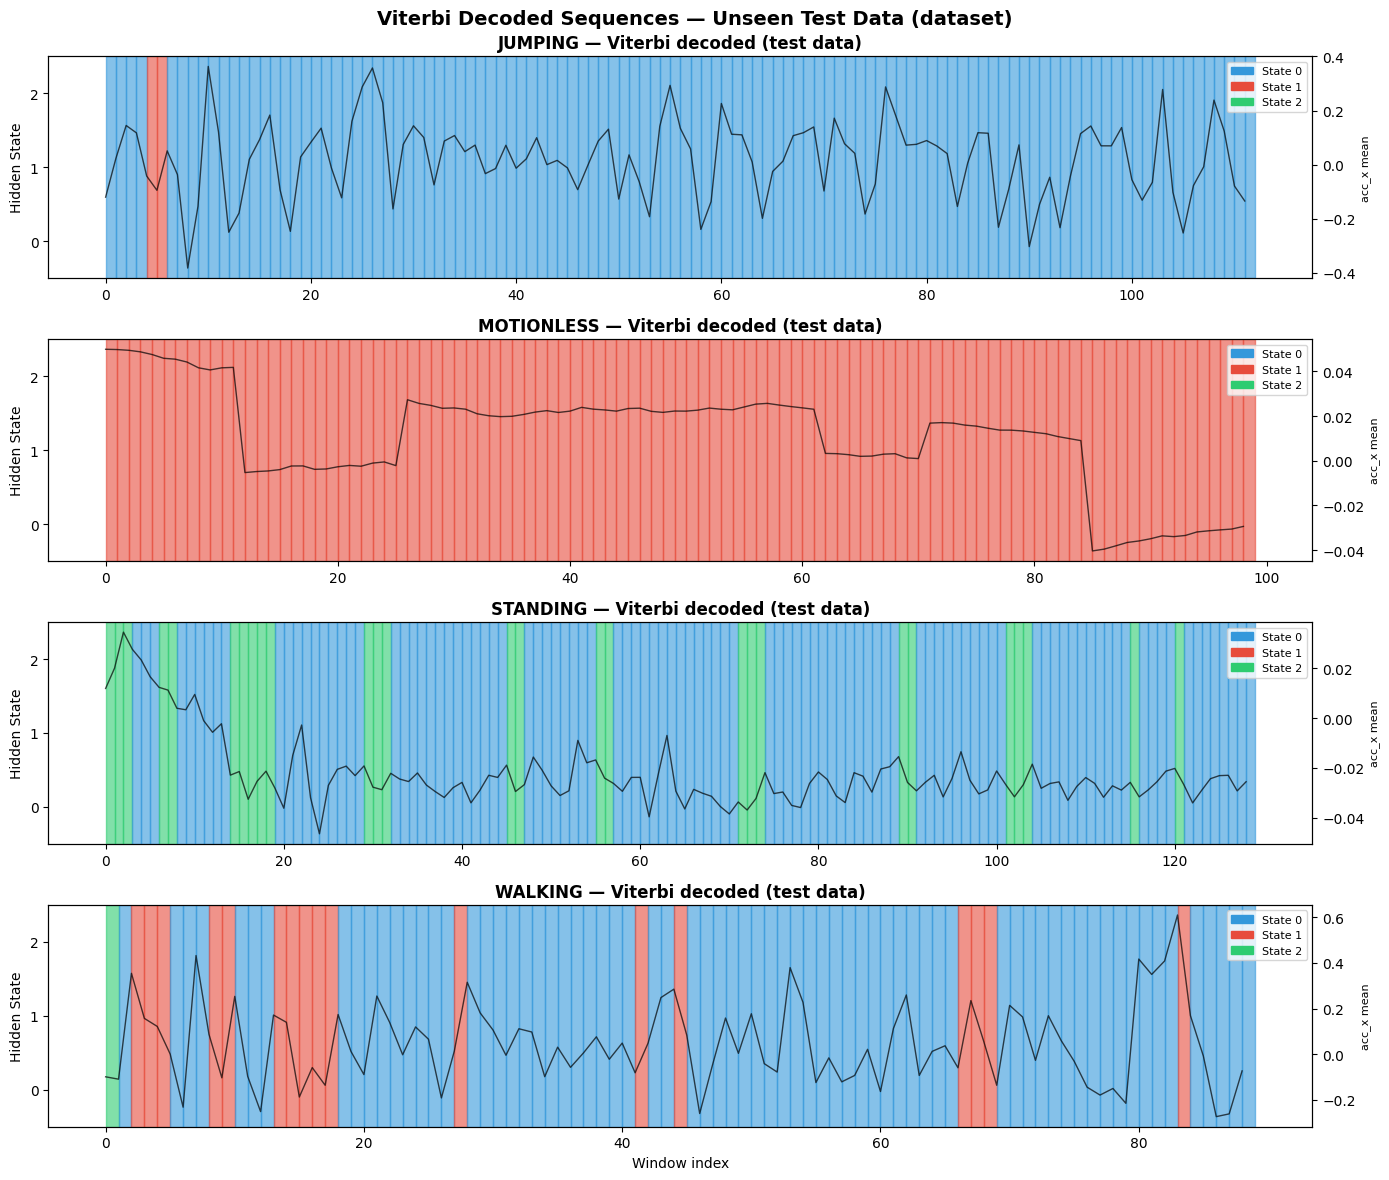

In [19]:
fig, axes = plt.subplots(4, 1, figsize=(14, 12))
colors_map = {0: '#3498db', 1: '#e74c3c', 2: '#2ecc71'}

for ax, activity in zip(axes, ACTIVITIES):
    mask  = (test_features['activity'] == activity)
    X_seq = X_test[mask]

    _, state_seq = models[activity].decode(X_seq, algorithm='viterbi')

    time_axis = np.arange(len(state_seq))
    for t, s in enumerate(state_seq):
        ax.axvspan(t, t + 1, color=colors_map[s], alpha=0.6)

    ax2 = ax.twinx()
    acc_signal = test_features[mask]['acc_x_mean'].values
    ax2.plot(time_axis[:len(acc_signal)], acc_signal[:len(time_axis)],
             color='black', linewidth=1, alpha=0.7)
    ax2.set_ylabel('acc_x mean', fontsize=8)

    ax.set_title(f'{activity.upper()} — Viterbi decoded (test data)', fontweight='bold')
    ax.set_ylabel('Hidden State')
    ax.set_yticks([0, 1, 2])
    ax.set_ylim(-0.5, 2.5)
    patches = [mpatches.Patch(color=colors_map[i], label=f'State {i}') for i in range(3)]
    ax.legend(handles=patches, loc='upper right', fontsize=8)

axes[-1].set_xlabel('Window index')
plt.suptitle('Viterbi Decoded Sequences — Unseen Test Data (dataset)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

#Sensitivity, Specificity & Accuracy Table

In [20]:
from sklearn.metrics import confusion_matrix

overall_acc = np.mean(y_pred == y_test)
print(f'Overall Accuracy on unseen test dataset: {overall_acc:.2%}')
print(f'Trained on: dataset_for_hmm  |  Tested on: dataset')
print()
print(f'{"Activity":<14} {"Samples":>10} {"Sensitivity":>13} {"Specificity":>13} {"Accuracy":>10}')
print('-' * 65)

for activity in ACTIVITIES:
    y_true_bin = (y_test == activity).astype(int)
    y_pred_bin = (y_pred == activity).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    print(f'{activity:<14} {int(y_true_bin.sum()):>10} {sensitivity:>13.2%} {specificity:>13.2%} {accuracy:>10.2%}')


Overall Accuracy on unseen test dataset: 85.08%
Trained on: dataset_for_hmm  |  Tested on: dataset

Activity          Samples   Sensitivity   Specificity   Accuracy
-----------------------------------------------------------------
jumping               112       100.00%        88.01%     91.14%
motionless             99       100.00%       100.00%    100.00%
standing              129       100.00%        91.33%     93.94%
walking                89        28.09%       100.00%     85.08%
